In [2]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline 
from IPython.display import Image

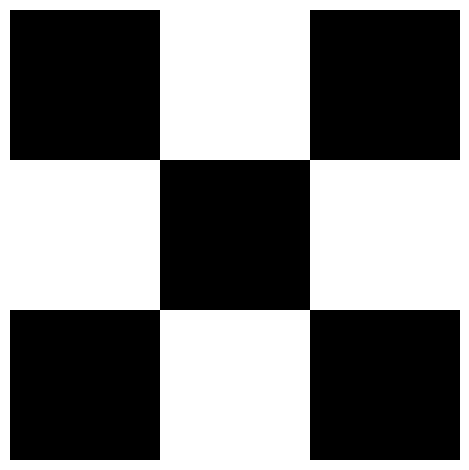

In [3]:
img = np.array([
                [[0, 0, 0], [255, 255, 255],[0, 0, 0]],
                [[255, 255, 255], [0, 0, 0],[255, 255, 255]],
                [[0, 0, 0], [255, 255, 255],[0, 0, 0]]
        ])
plt.imshow(img)
plt.axis('off')
plt.tight_layout()
plt.savefig("pixels.jpg")

In [4]:
img_cb = cv.imread("pixels.jpg", 0)
print(img_cb)

[[255 255 255 ... 255 255 255]
 [255 255 255 ... 255 255 255]
 [255 255 255 ... 255 255 255]
 ...
 [255 255 255 ... 255 255 255]
 [255 255 255 ... 255 255 255]
 [255 255 255 ... 255 255 255]]


In [5]:
#Image attributes
print(img_cb.shape, img_cb.dtype)

(480, 640) uint8


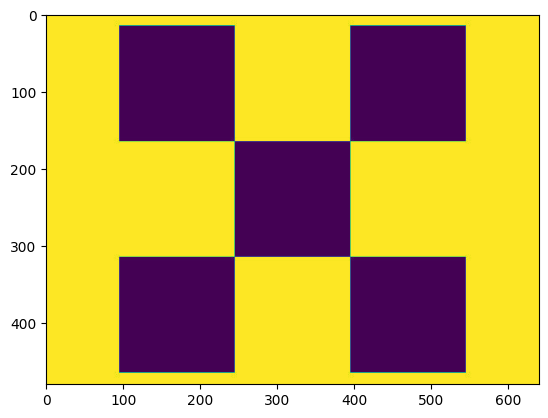

In [6]:
plt.imshow(img_cb)

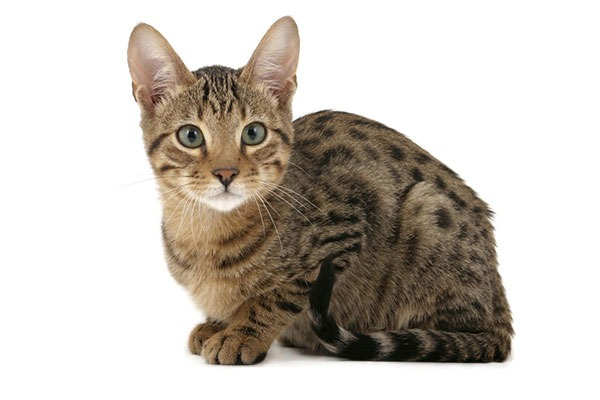

In [7]:
Image('../Images/cat.jpeg')

In [8]:
cat = cv.imread("../Images/cat.jpeg", 1)
print(f"Shape: {cat.shape}\nType: {cat.dtype}")

Shape: (400, 600, 3)
Type: uint8


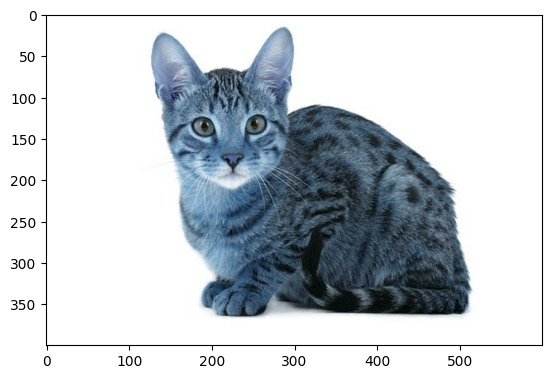

In [9]:
plt.imshow(cat)
#Here, OpenCV stores images in BGR whereas plt expects images to be in RGB.

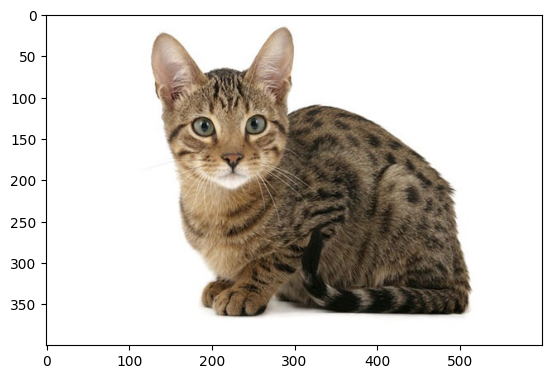

In [10]:
reversed_cat = cat[:, :, ::-1] #Reverse channels to correctly display the image.
plt.imshow(reversed_cat)

## Splitting and merging channels.


Text(0.5, 1.0, 'Merged output')

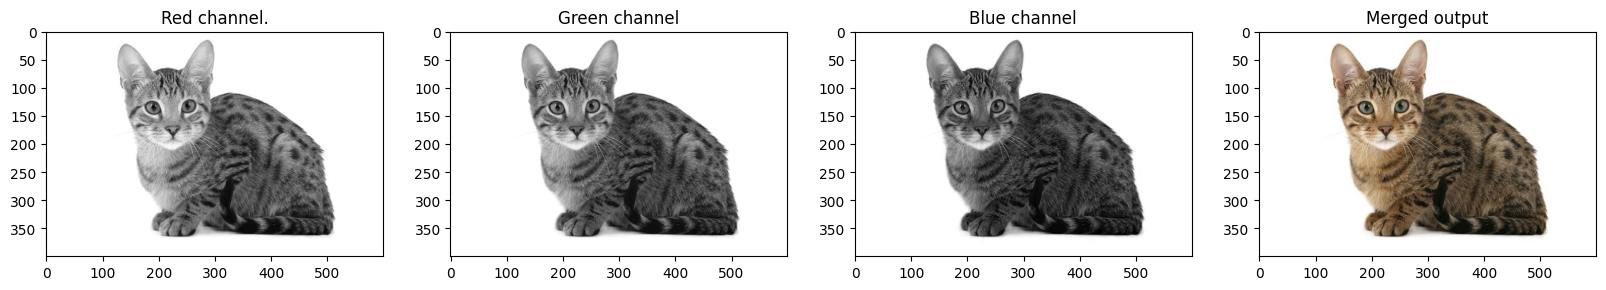

In [25]:
# split the img into B, G, R  componets.
img_bgr = cv.imread("../Images/cat.jpeg", cv.IMREAD_COLOR)
b, g, r = cv.split(img_bgr)

#show the channels.
plt.figure(figsize=(20, 8))
plt.subplot(141);plt.imshow(r, cmap="gray");plt.title("Red channel.");
plt.subplot(142);plt.imshow(g, cmap="gray");plt.title("Green channel");
plt.subplot(143);plt.imshow(b, cmap="gray");plt.title("Blue channel");

img_merged = cv.merge((b, g, r))
plt.subplot(144);plt.imshow(img_merged[:, :, ::-1]);plt.title("Merged output")

## Changing color spaces.

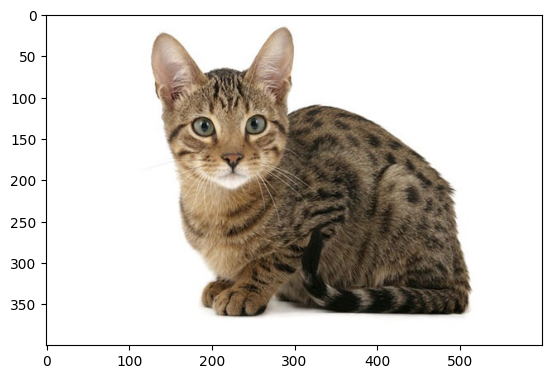

In [26]:
cat = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)
plt.imshow(cat)

- Changing to HSV color space.

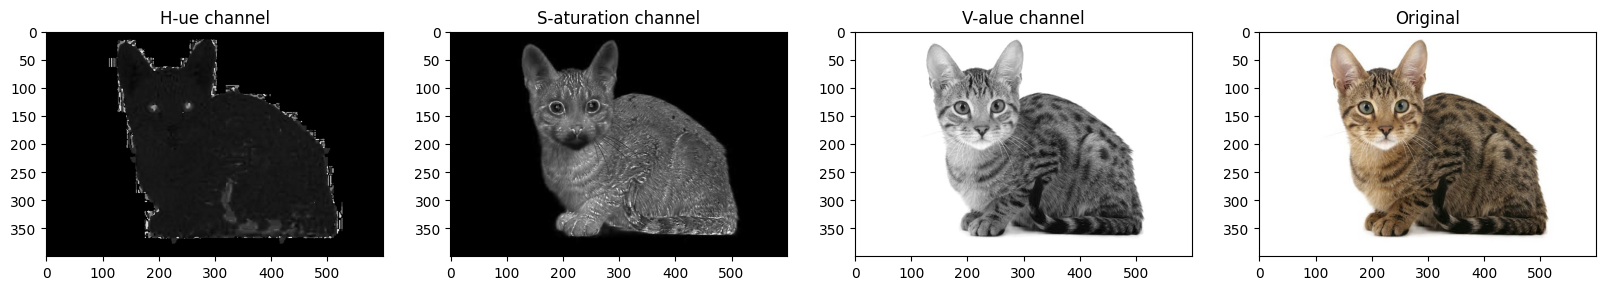

In [29]:
img_hsv = cv.cvtColor(img_bgr, cv.COLOR_BGR2HSV)
h, s, v = cv.split(img_hsv)

plt.figure(figsize=(20, 5))
plt.subplot(141);plt.imshow(h, cmap="gray");plt.title("H-ue channel");
plt.subplot(142);plt.imshow(s, cmap="gray");plt.title("S-aturation channel");
plt.subplot(143);plt.imshow(v, cmap="gray");plt.title("V-alue channel");
plt.subplot(144);plt.imshow(cat);plt.title("Original");

- Modifying individual channel.

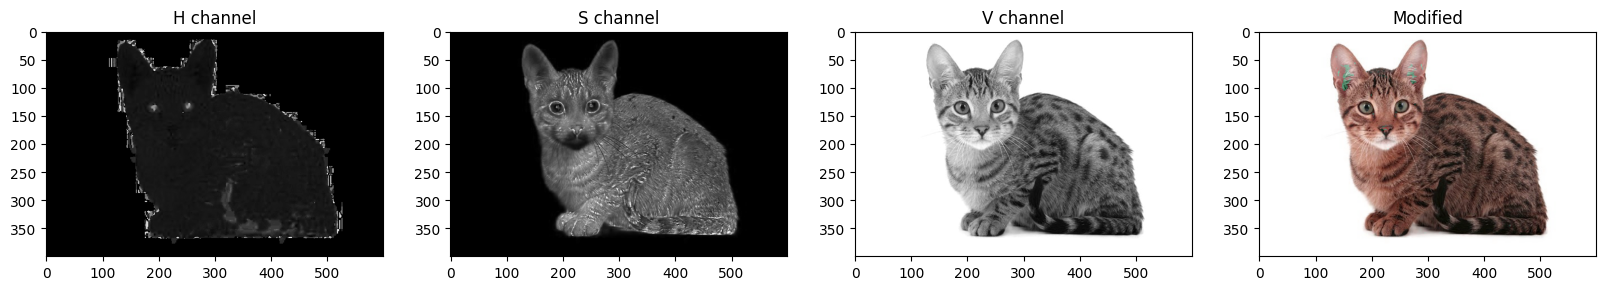

In [34]:
h_new = h - 10
img_merged = cv.merge((h_new, s, v))
img_rgb = cv.cvtColor(img_merged, cv.COLOR_HSV2RGB)

#PLot.
plt.figure(figsize=(20, 5))
plt.subplot(141);plt.imshow(h, cmap="gray");plt.title("H channel");
plt.subplot(142);plt.imshow(s, cmap="gray");plt.title("S channel");
plt.subplot(143);plt.imshow(v, cmap="gray");plt.title("V channel");
plt.subplot(144);plt.imshow(img_rgb);plt.title("Modified");

### Cropping images.

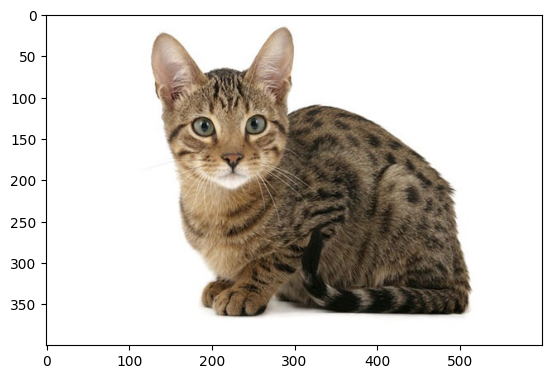

In [38]:
cat = cv.imread("../Images/cat.jpeg", cv.IMREAD_COLOR)
cat = cat[:, :, ::-1]
plt.imshow(cat)

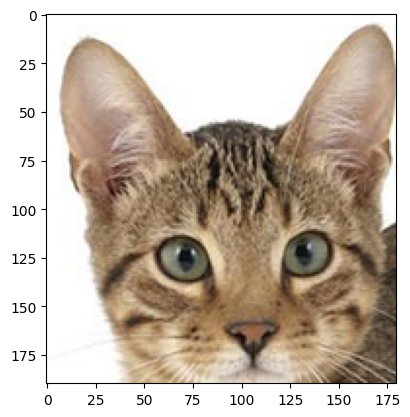

In [39]:
crop_region = cat[10:200, 120:300]
plt.imshow(crop_region)

### Resizing images.
- dst = resize(size, dsize[, dst[, fx[, fy[, interpolation]]]] )

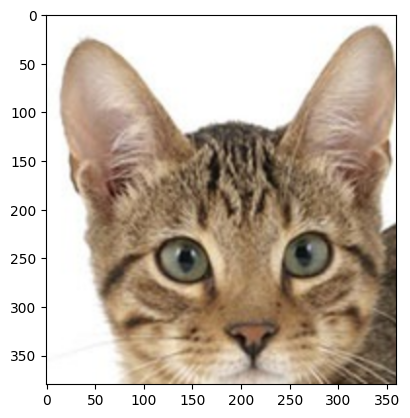

In [40]:
#Method 1: specifying fx, fy.
resizes_crop_2x = cv.resize(crop_region, None, fx=2, fy=2)
plt.imshow(resizes_crop_2x)

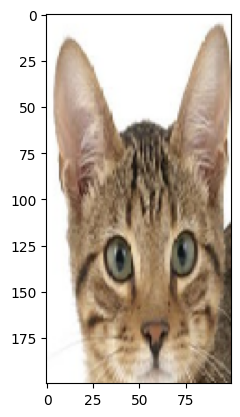

In [41]:
#Specifying the exact size of the output image.
desired_width = 100
desired_height = 200
dim = (desired_width, desired_height)

resize_crop = cv.resize(crop_region, dsize=dim, interpolation=cv.INTER_AREA)
plt.imshow(resize_crop)

- Resizing while maintainig aspect ratio.

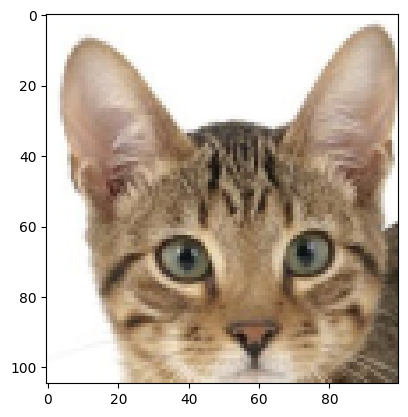

In [42]:
desired_width = 100
aspect_ratio = desired_width / crop_region.shape[1]
desired_height = int(crop_region.shape[0] * aspect_ratio)
dim = (desired_width, desired_height)

resize_crop = cv.resize(crop_region, dsize=dim, interpolation=cv.INTER_AREA)
plt.imshow(resize_crop)

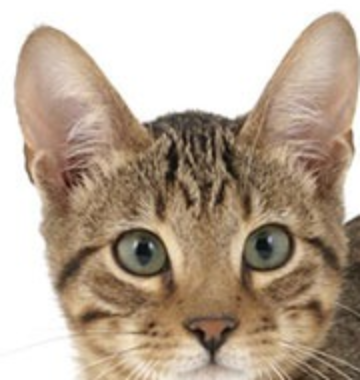

In [43]:
resizes_crop_2x = resizes_crop_2x[:, :, ::-1]

cv.imwrite("resized_cat_2x.png", resizes_crop_2x)

Image("resized_cat_2x.png")

### Flipping images.

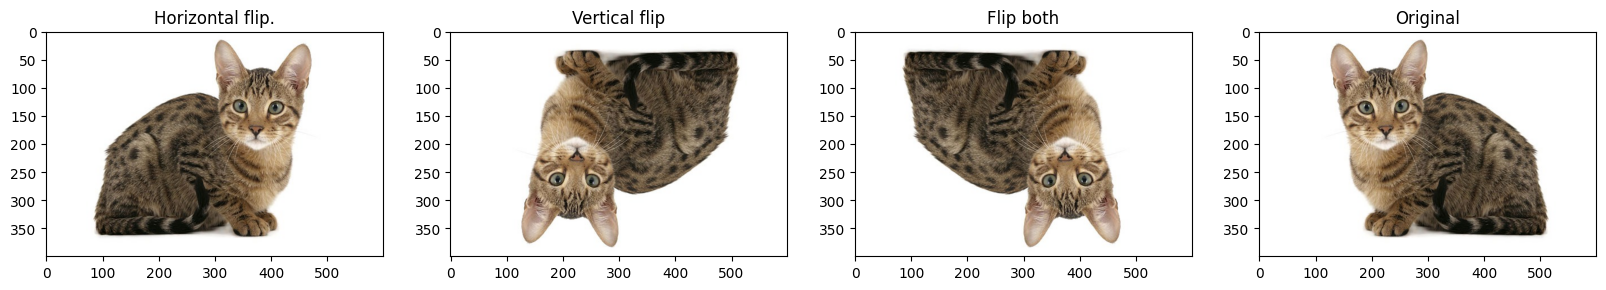

In [50]:
cat_flip_hor = cv.flip(cat, 1)
cat_flip_vert = cv.flip(cat, 0)
cat_flip_both = cv.flip(cat, -1)

plt.figure(figsize=(20, 5))
plt.subplot(141);plt.imshow(cat_flip_hor);plt.title("Horizontal flip.");
plt.subplot(142);plt.imshow(cat_flip_vert);plt.title("Vertical flip");
plt.subplot(143);plt.imshow(cat_flip_both);plt.title("Flip both");
plt.subplot(144);plt.imshow(cat);plt.title("Original");

## Annotating images.

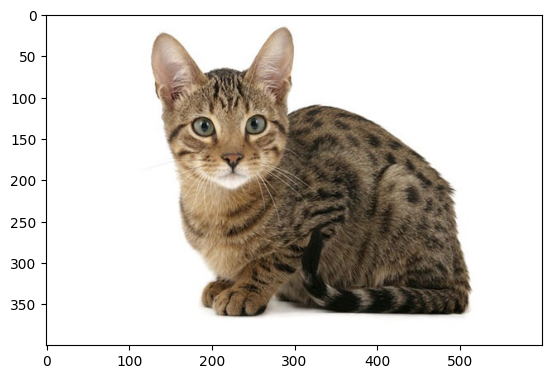

In [52]:
image = cv.imread("../Images/cat.jpeg")
plt.imshow(image[:, :, ::-1])

- Drawing a line.
 -- img = cv.line(img, pt1, pt2, color[, thickness[, lineType[, shift]]])

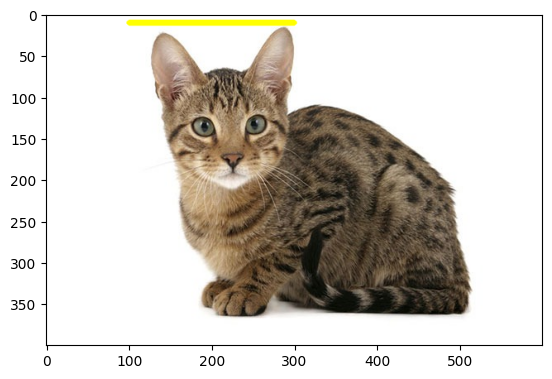

In [54]:
imageline = image.copy()

cv.line(imageline, (100, 10), (300, 10), (0, 255, 255), thickness=5, lineType=cv.LINE_AA)

plt.imshow(imageline[:, :, ::-1])

- Drawing a circle.
    - img = cv.circle(img, center, radius, color[, thickness[, LineType[, shift]]])

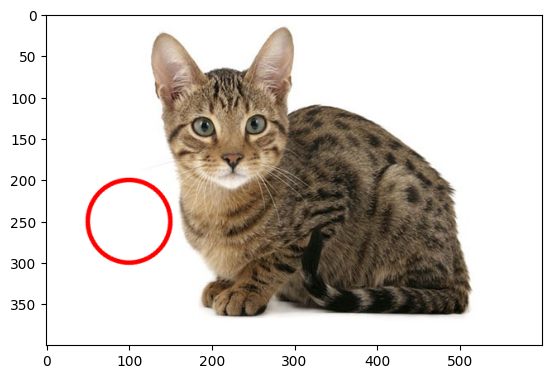

In [57]:
imageCircle = image.copy()

cv.circle(imageCircle, (100, 250), 50, (0, 0, 255), thickness=3, lineType=cv.LINE_AA)

plt.imshow(imageCircle[:, :, ::-1])

- Drawing a rectangle.
    - img = cv2.rectangle(img, pt1, pt2, color[, thickness[, LineType[, shift]]])

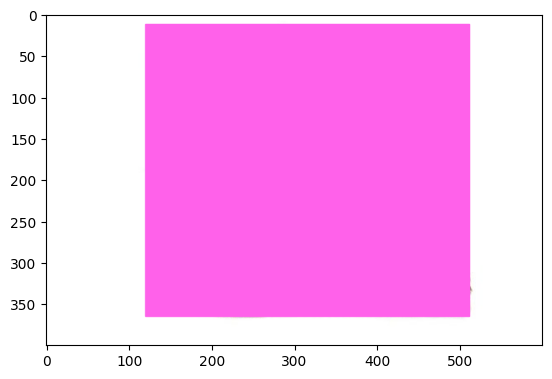

In [89]:
imageRec = image.copy()

cv.rectangle(imageRec, (120, 12), (512, 365), (234, 97, 255), -2, lineType=cv.LINE_AA)

plt.imshow(imageRec[:, :, ::-1])

- Adding Text.
    - img = cv.putText(img, text, org, fontFace, fontScale, color[, thickness[, lineType[, bottomLeftOrigin]]])

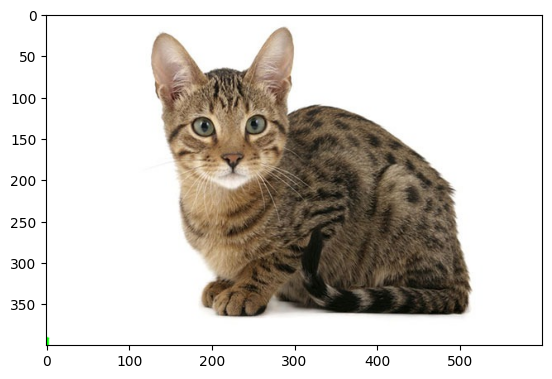

In [88]:
imageText = image.copy()
text = "Brown kitty cat, born 17th April 2021."
fontScale = -1.8
fontFace = cv.FONT_HERSHEY_PLAIN
fontColor = (0, 255, 0)
fontThickckness = 2

cv.putText(imageText, text, (5, 390), fontFace, fontScale, fontColor, fontThickckness, cv.LINE_AA)

plt.imshow(imageText[:, :, ::-1])